<a href="https://colab.research.google.com/github/prem1555/Integrated-Retail-Analytics-For-Store-Optimization/blob/main/Retail_Analytics_for_Store_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Integrated Retail Analytics for Store Optimization

##### **Project Type**    - Advanced Machine Learning
##### **Contribution**    - Individual
##### **Submitted by -** Premsagar Palled

# **Project Summary -**

The **Integrated Retail Analytics for Store Optimization** project is a data-driven initiative focused on improving performance of retail store through advanced analytics and machine learning techniques.Now-a-days competitive retail environment , businesses should move from using traditional reporting to adopt intelligent systems that can discover hidden patterns and predict future demand and support strategic decision-making.

This project aims to bridge that gap by transforming raw retail data into actionable business insights.


**Dataset**

In this project we use three interconnected datasets contains sales-level, store-level, and external feature information.

- The sales dataset contains weekly sales for different stores and department along with holiday indicator.
- The store dataset provides details such as store type and size, which helps in understanding structural differences across locations.
- The features dataset contains external factors such as Temperature, Fuel price, Markdowns, Consumer Price Index, and unemployment rate.

By using these datasets, the project identifies both internal business dynamics and external economic influences which affects sales performance.

**Key Objectives:**
- Analyze Past Retail data to identify trends, patterns, and anomalies.
- Using Machine Learning and Time-Series models to Forecast weekly
sales for stores and Departments.
- Identifies the impact of external economic and environmental factors on sales.
- Divide stores and departments based on performance and behavioral patterns.
- Give Actionable insights to improve marketing strategies and planning inventory.

**Business Impact:**
- Helps Retailers to make strategic decisions by providing insights into sales trends and demand fluctuations.
- Helps in optimizing inventory levels, reducing stockouts and overstock situations.
- By understanding store segments and external influences, businesses can design targeted marketing campaigns and pricing strategies.
- Anomaly detection helps in capturing irregular patterns that may indicate issues or chances for growth.

# **GitHub Link -**

https://github.com/prem1555/Integrated-Retail-Analytics-For-Store-Optimization

# **Problem Statement**


The objective of this project is to analyze retail sales data to:

- Identify anomalies in sales patterns
- Understand seasonal and holiday impacts
- Segment stores based on performance
- Forecast future sales
- Analyze external economic factors
- Develop actionable business strategies

The final goal is to improve inventory planning,
marketing effectiveness, and store performance.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Anomaly Detection
from sklearn.ensemble import IsolationForest

# Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model Evaluation
from sklearn.metrics import mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# Load Dataset Files
# ============================================================
sales = pd.read_csv("/content/drive/MyDrive/Retail_Analytics_for_Store_Optimization/Retail_Dataset/sales data-set.csv")
features = pd.read_csv("/content/drive/MyDrive/Retail_Analytics_for_Store_Optimization/Retail_Dataset/Features data set.csv")

stores = pd.read_csv("/content/drive/MyDrive/Retail_Analytics_for_Store_Optimization/Retail_Dataset/stores data-set.csv")

### Dataset First View

In [4]:
# Display first 5 records

sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [5]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [6]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
print("Sales Dataset - \nRows & Columns :", sales.shape)

Sales Dataset - 
Rows & Columns : (421570, 5)


In [8]:
print("Features Dataset - \nRows & Columns :", features.shape)

Features Dataset - 
Rows & Columns : (8190, 12)


In [9]:
print("Stores Dataset - \nRows & Columns :", stores.shape)

Stores Dataset - 
Rows & Columns : (45, 3)


### Dataset Information

In [10]:
# Dataset Info
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [11]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.00,11.00,22.00,33.0000,45.00
Dept,421570.0,44.260317,30.492054,1.00,18.00,37.00,74.0000,99.00
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.94,2079.65,7612.03,20205.8525,693099.36


In [12]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [13]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,8190.0,23.000000,12.987966,1.000,12.000000,23.000000,34.000000,45.000000
Temperature,8190.0,59.356198,18.678607,-7.290,45.902500,60.710000,73.880000,101.950000
Fuel_Price,8190.0,3.405992,0.431337,2.472,3.041000,3.513000,3.743000,4.468000
MarkDown1,4032.0,7032.371786,9262.747448,-2781.450,1577.532500,4743.580000,8923.310000,103184.980000
MarkDown2,2921.0,3384.176594,8793.583016,-265.760,68.880000,364.570000,2153.350000,104519.540000
MarkDown3,3613.0,1760.100180,11276.462208,-179.260,6.600000,36.260000,163.150000,149483.310000
MarkDown4,3464.0,3292.935886,6792.329861,0.220,304.687500,1176.425000,3310.007500,67474.850000
MarkDown5,4050.0,4132.216422,13086.690278,-185.170,1440.827500,2727.135000,4832.555000,771448.100000
CPI,7605.0,172.460809,39.738346,126.064,132.364839,182.764003,213.932412,228.976456
Unemployment,7605.0,7.826821,1.877259,3.684,6.634000,7.806000,8.567000,14.313000


In [14]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [15]:
stores.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,45.0,23.0,13.133926,1.0,12.0,23.0,34.0,45.0
Size,45.0,130287.6,63825.271991,34875.0,70713.0,126512.0,202307.0,219622.0


#### Duplicate Values

In [16]:
# Dataset Duplicate Value Count
print(sales.duplicated().sum())
print(features.duplicated().sum())
print(stores.duplicated().sum())

0
0
0


#### Missing Values/Null Values

In [17]:
# Missing Values/Null Values Count

sales.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [18]:
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


In [19]:
stores.isnull().sum()

,0
Store,0
Type,0
Size,0


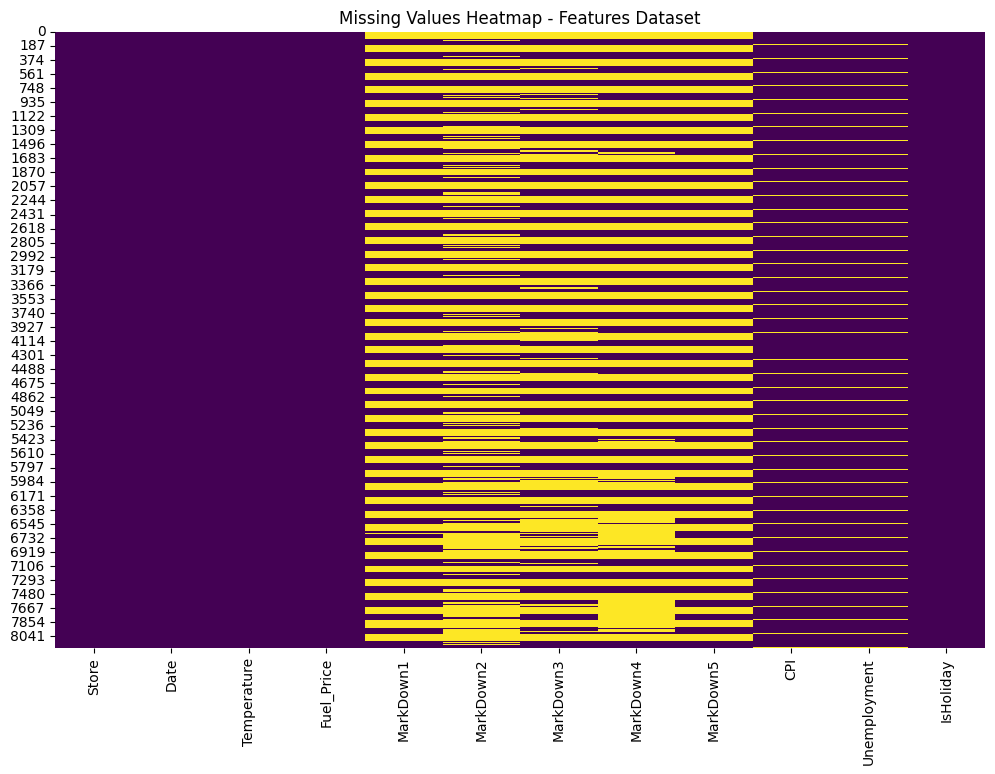

In [20]:
# Visualizing the missing values
plt.figure(figsize = (12,8))

sns.heatmap(features.isnull(), cbar = False, cmap = 'viridis')
plt.title('Missing Values Heatmap - Features Dataset')
plt.show()

### What did you know about your dataset?

- The sales dataset is large (421570 records) and contains weekly sales at store and department level, making it suitable for detailed analysis and forecasting.

- The stores dataset is small and clean, providing static information like store type and size, which can be useful for segmentation and feature engineering.

- The features dataset includes external factors such as temperature, fuel price, CPI, unemployment, and markdowns, which are important for understanding sales behavior.

- No duplicate records are present in any dataset, so no duplicate handling is required.

- No missing values are found in sales and stores datasets, indicating clean core data.

- Significant missing values are present in markdown columns (MarkDown1–5), which likely represent weeks with no promotions and need proper handling.

- The Date column is in object format and needs to be converted to datetime for time-based analysis.

Overall the datasets are well-structured and rich, combining internal sales data with external economic indicators, making them highly suitable for advanced analytics, anomaly detection, and demand forecasting.


## ***2. Understanding Your Variables***

In [21]:
# Sales Dataset Columns
print(f"Columns in Sales Dataset :\n{sales.columns}")

Columns in Sales Dataset :
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


In [22]:
# Stores Dataset Columns
print(f"Columns in Stores Dataset :\n{stores.columns}")

Columns in Stores Dataset :
Index(['Store', 'Type', 'Size'], dtype='object')


In [23]:
# Dataset Columns
print(f"Columns in Features Dataset :\n{features.columns}")

Columns in Features Dataset :
Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')


### Variables Description

**Sales Dataset:**
- **Store:** Unique identifier for each store
- **Dept:** Department number within the store
- **Date:** Week of sales
- **Weekly_Sales:** Total sales for the given store and department in a week (Target Variable)
- **IsHoliday:** Boolean indicating whether the week includes a holiday
---
**Stores Dataset:**
- **Store:** Unique store identifier
- **Type:** Store category (A, B, C)
- **Size:** Size of the store (area)
---
**Features Dataset:**
- **Store:** Store identifier
- **Date:** Week of observation
- **Temperature:** Average temperature during the week
- **Fuel_Price:** Cost of fuel in the region
- **MarkDown1–5:** Promotional markdown values (can be null if no promotion)
- **CPI:** Consumer Price Index (economic indicator)
- **Unemployment:** Unemployment rate
- **IsHoliday:** Indicates if the week is a holiday

### Check Unique Values for each variable.

In [24]:
# ============================================================
# Check number of unique values in each column
# ============================================================

print("Sales Dataset unique values - \n")
for col in sales.columns:
    print(f"{col} : {sales[col].nunique()}")

Sales Dataset unique values - 

Store : 45
Dept : 81
Date : 143
Weekly_Sales : 359464
IsHoliday : 2


In [25]:
print("Stores Dataset unique values - \n")
for col in stores.columns:
    print(f"{col} : {stores[col].nunique()}")

Stores Dataset unique values - 

Store : 45
Type : 3
Size : 40


In [26]:
print("Features Dataset unique values - \n")
for col in features.columns:
    print(f"{col} : {features[col].nunique()}")

Features Dataset unique values - 

Store : 45
Date : 182
Temperature : 4178
Fuel_Price : 1011
MarkDown1 : 4023
MarkDown2 : 2715
MarkDown3 : 2885
MarkDown4 : 3405
MarkDown5 : 4045
CPI : 2505
Unemployment : 404
IsHoliday : 2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [27]:
# ===========================================================
# Convert Date columns in both datasets
# ===========================================================

sales['Date'] = pd.to_datetime(
    sales['Date'],
    format='%d/%m/%Y'
)

features['Date'] = pd.to_datetime(
    features['Date'],
    format='%d/%m/%Y'
)

In [28]:
# ============================================================
# Merge Sales and Features Dataset
# ============================================================

df = pd.merge(
    sales,
    features,
    on=['Store','Date','IsHoliday'],
    how='left'
)

# ============================================================
# Merge Store Information
# ============================================================

df = pd.merge(
    df,
    stores,
    on='Store',
    how='left'
)

In [29]:
# ============================================================
# Handling Missing values in markdown columns.
# ============================================================

markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

for col in markdown_cols:
    df[col] = df[col].fillna(0)

### What all manipulations have you done and insights you found?

Manipulations Done:
- Converted Date column into datetime format for proper time-based analysis.
- Merged sales, features, and stores datasets using Store and Date.
- Handled missing values in MarkDown columns by replacing them with 0, assuming no promotions during those weeks.

Insights Found:

- A large number of missing values were present in MarkDown columns, indicating that promotional activities are not frequent across all stores and weeks.
- No missing values were found in core variables like Weekly_Sales, Temperature, CPI, and Unemployment, ensuring data reliability.
- The dataset now combines sales performance with external and store-level factors, making it suitable for deeper analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Weekly Sales Distribution

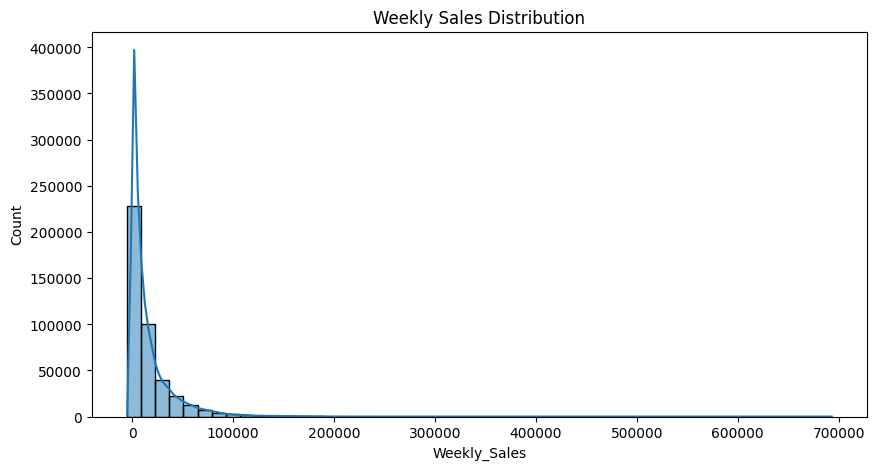

In [30]:
# Chart - 1 - Weekly Sales Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['Weekly_Sales'], bins=50, kde=True)

plt.title("Weekly Sales Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

To understand how sales values are distributed.

##### 2. What is/are the insight(s) found from the chart?

Most sales are low, with very few extremely high values (right-skewed distribution).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help us to identify weeks in which there are higher sales and with this info the company can plan the inventory accordingly.

#### Chart - 2 : Sales per Month

Text(0.5, 1.0, 'Sum of weekly sales per month')

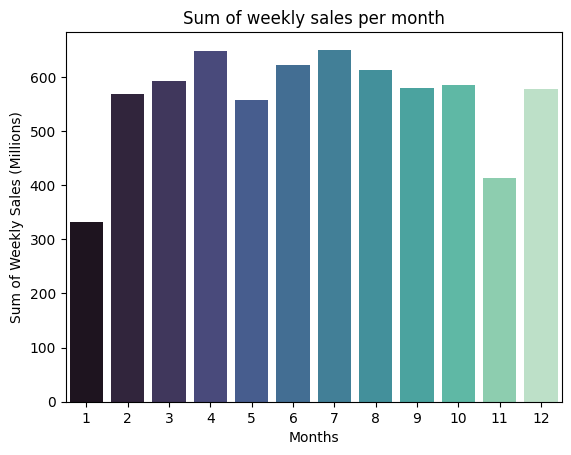

In [31]:
# Chart - 2 visualization code

# Sum of weekly sales each month, across the years
monthly_sales = df.groupby(df.Date.dt.month)['Weekly_Sales'].sum()/1000000
sns.barplot(x = monthly_sales.index, y = monthly_sales.values, palette='mako')
plt.xlabel('Months')
plt.ylabel('Sum of Weekly Sales (Millions)')
plt.title("Sum of weekly sales per month")

##### 1. Why did you pick the specific chart?

To identify, which month the business is getting higher sales.

##### 2. What is/are the insight(s) found from the chart?

- April and july are the months with highest sales followed by june, august, september and october.
- November shows a dip in purchasing activity, likely because customers are waiting for upcoming sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help business create better selling strategies and also can help the business plan the offers and promotions period.

#### Chart - 3 : Sales by Year

Text(0.5, 0, 'Years')

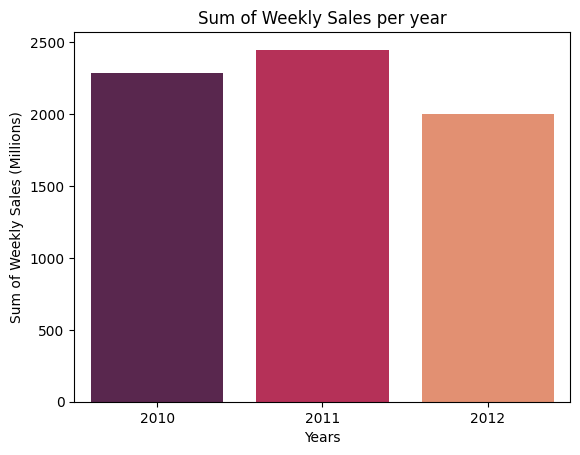

In [32]:
# Chart - 3 visualization code
yearly_sales = df.groupby(df.Date.dt.year)['Weekly_Sales'].sum()/1000000
sns.barplot(x = yearly_sales.index, y = yearly_sales.values, palette = 'rocket')
plt.title("Sum of Weekly Sales per year")
plt.ylabel("Sum of Weekly Sales (Millions)")
plt.xlabel("Years")


##### 1. Why did you pick the specific chart?

To see which year has the highest sales.

##### 2. What is/are the insight(s) found from the chart?

In our data, 2011 is the year in which the company made the highest sales followed bu 2010 and 2012.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help the business to identify the reason behind the higher sales and can take necessary actions to increase the sales in coming years.

#### Chart - 4 : Store type Distribution

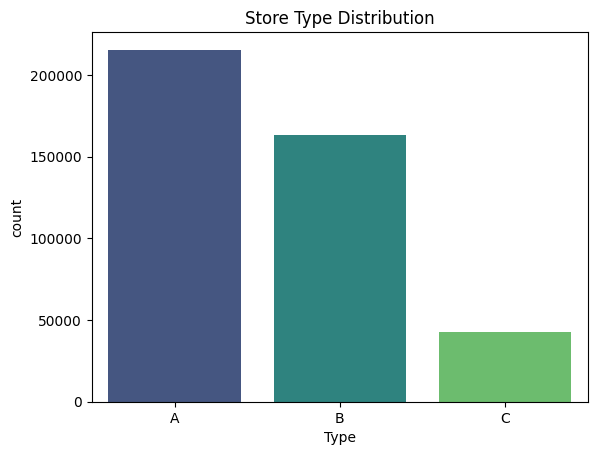

In [33]:
# Chart - 4 visualization code

sns.countplot(x='Type', data=df, palette='viridis')
plt.title("Store Type Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To see distribution of store categories.

##### 2. What is/are the insight(s) found from the chart?

Type A stores are the most, followed by B, while C stores are very few.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help in comparing performance by store type.

#### Chart - 5 : Fule Price Distribution

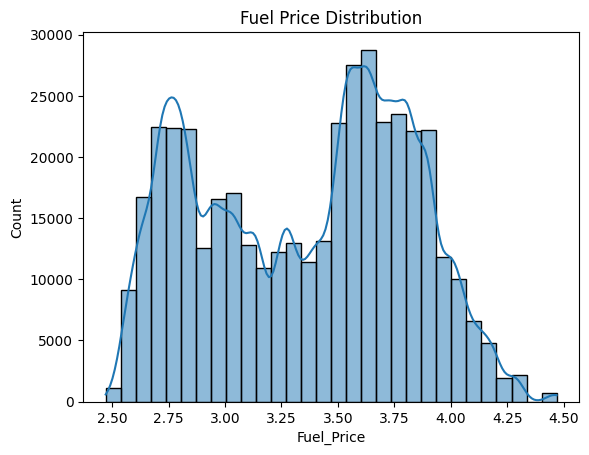

In [34]:
# Chart - 5 visualization code
# Fuel Price Distribution

sns.histplot(df['Fuel_Price'], bins=30, kde=True)
plt.title("Fuel Price Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Fuel prices show moderate variation with some clustering.

##### 2. What is/are the insight(s) found from the chart?

Fuel price shows moderate variations with some clustering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help understand the impact of fuel price on customer spending.

#### Chart - 6 : Sales by store type & holiday

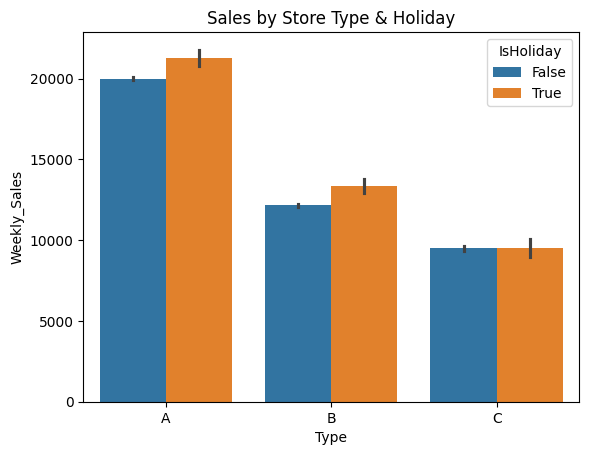

In [35]:
# Chart - 6 visualization code

sns.barplot(x='Type', y='Weekly_Sales', hue='IsHoliday', data=df)
plt.title("Sales by Store Type & Holiday")
plt.show()

##### 1. Why did you pick the specific chart?

To observe the impact of store type and holiday on sales.

##### 2. What is/are the insight(s) found from the chart?

Store A & B gets higher sales on holidays but store C gets equal sales on holiday and non-holidays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help create targetted promotions.

#### Chart - 7 : Average Unemployment Rate across Time

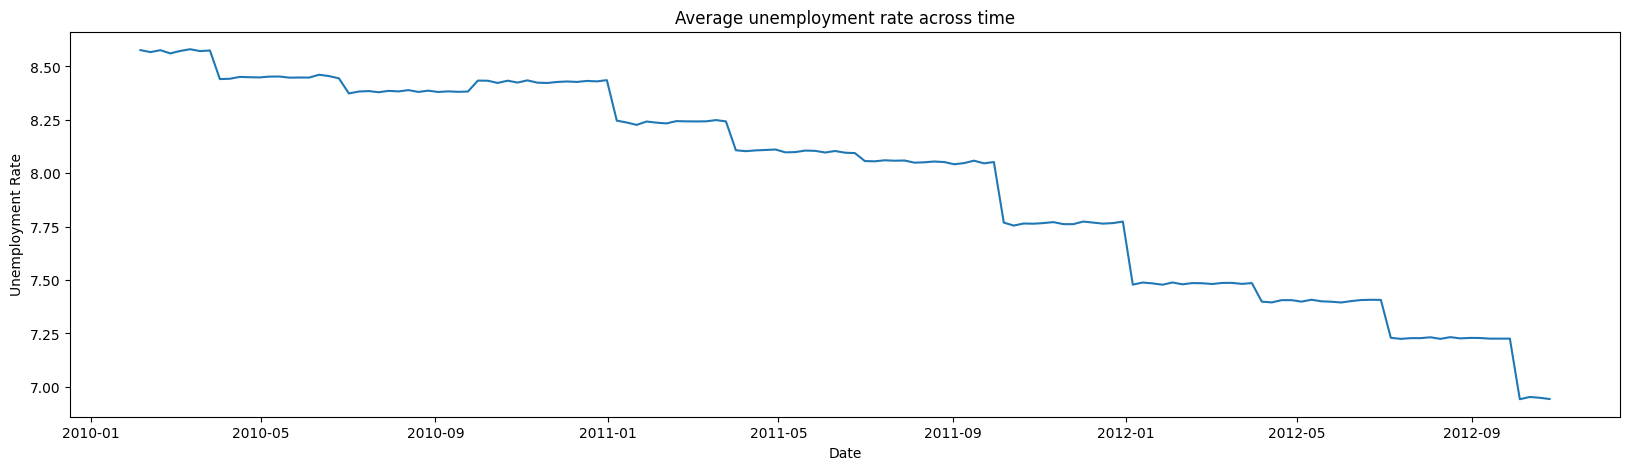

In [36]:
# Chart - 7 : Unemployment across time

# Average rate of unemployment each date for all the different outlets
unemp_rate = df.groupby(by = ['Date'], as_index= False)['Unemployment'].mean()


plt.figure(figsize = (20,5))
plt.plot(unemp_rate.Date, unemp_rate.Unemployment)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.title("Average unemployment rate across time")
plt.show()

##### 1. Why did you pick the specific chart?

To check for the average unemployment rate over time.

##### 2. What is/are the insight(s) found from the chart?

Over the period from January 2010 to December 2012, we have noted a gradual decrease in the unemployment rate. This result in improving the purchasing power of the customer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help us understand the purchasing power of the customers.

#### Chart - 8 : Sum of Sales across departments

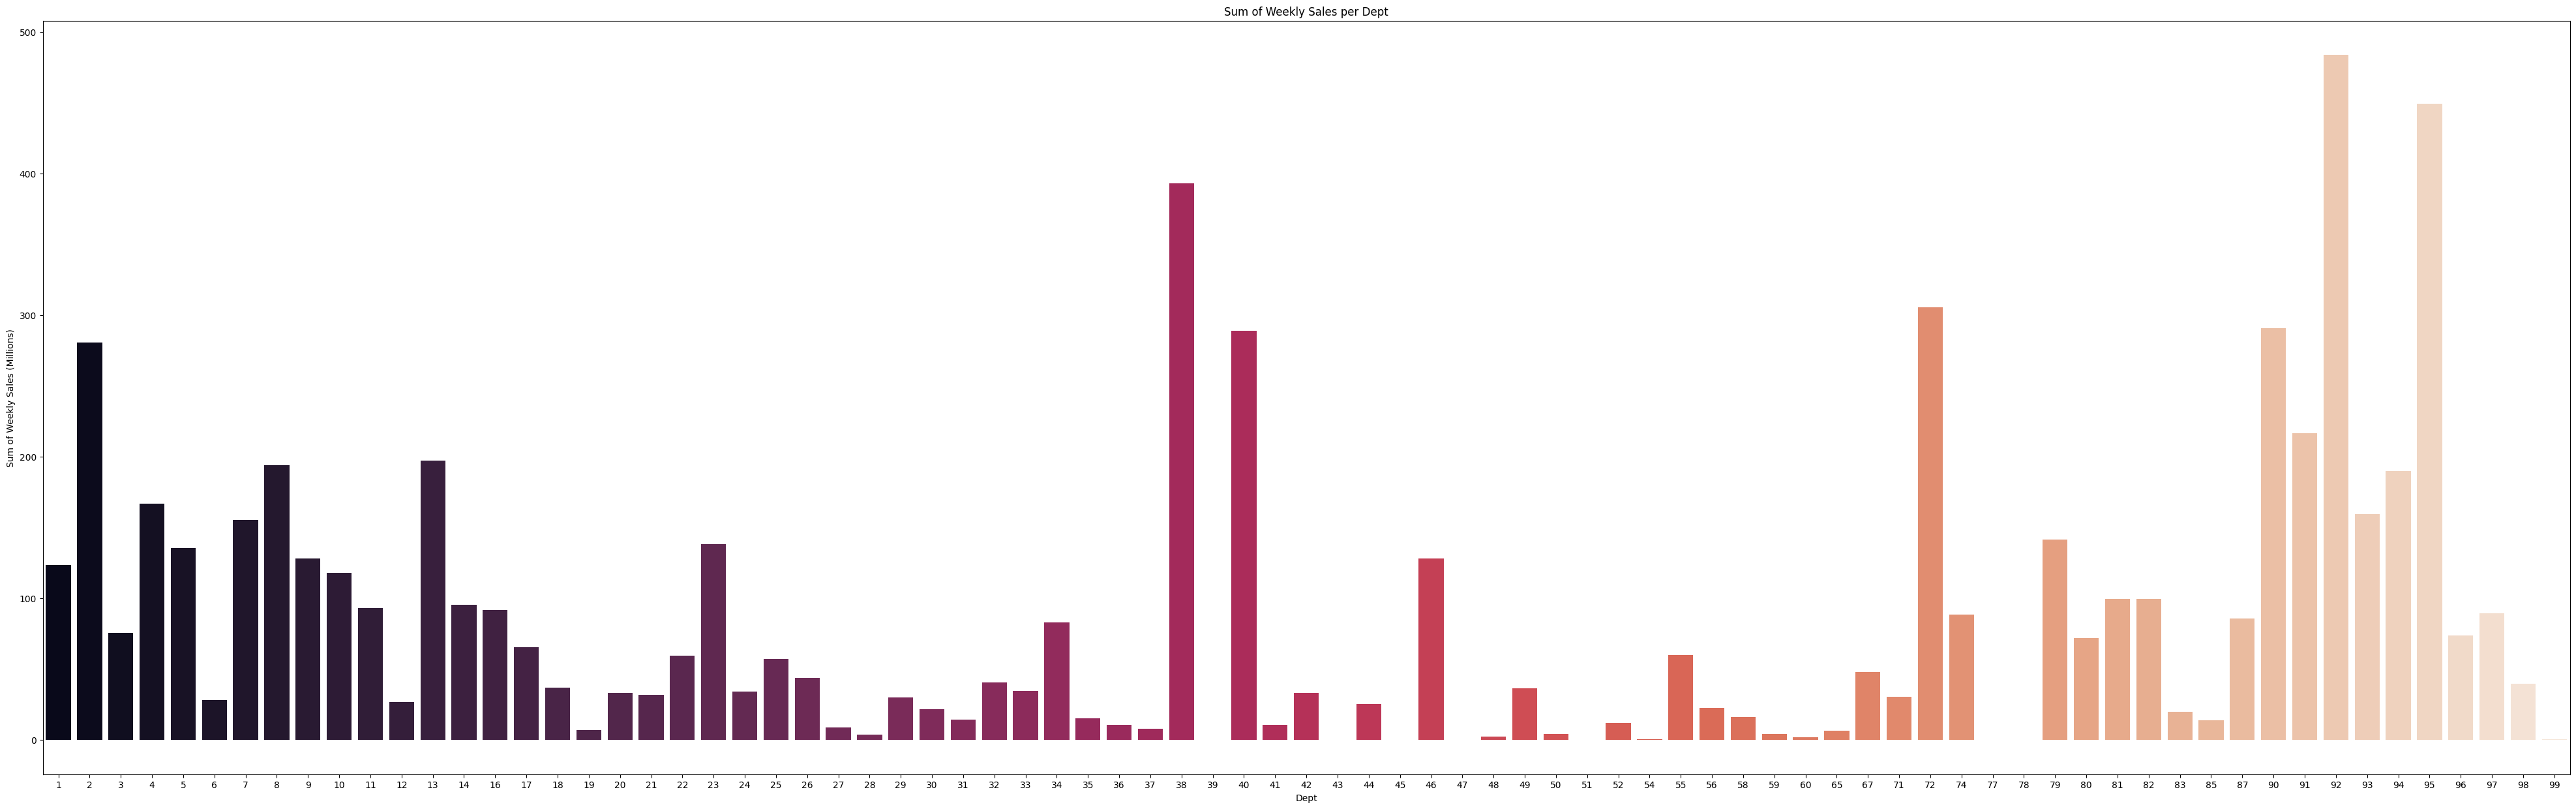

In [37]:
# Chart - 8 visualization code

# Sum of weekly sales across Department
dept_sales = df.groupby(by = ['Dept'], as_index= False)['Weekly_Sales'].sum()
dept_sales['Weekly_Sales'] = dept_sales['Weekly_Sales']/1000000
plt.figure(figsize=(50,15))
sns.barplot(x = dept_sales.Dept, y = dept_sales.Weekly_Sales , data = dept_sales, palette ='rocket')
plt.xlabel('Dept')
plt.ylabel('Sum of Weekly Sales (Millions)')
plt.title('Sum of Weekly Sales per Dept')
plt.show()

##### 1. Why did you pick the specific chart?

To understand sales by departments.

##### 2. What is/are the insight(s) found from the chart?

Department 38, 92,95 have the highest sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps indentifying the weak department to take necessary actions in terms of promotion or planning to increase sales.

#### Chart - 9 : Correlation Heatmap

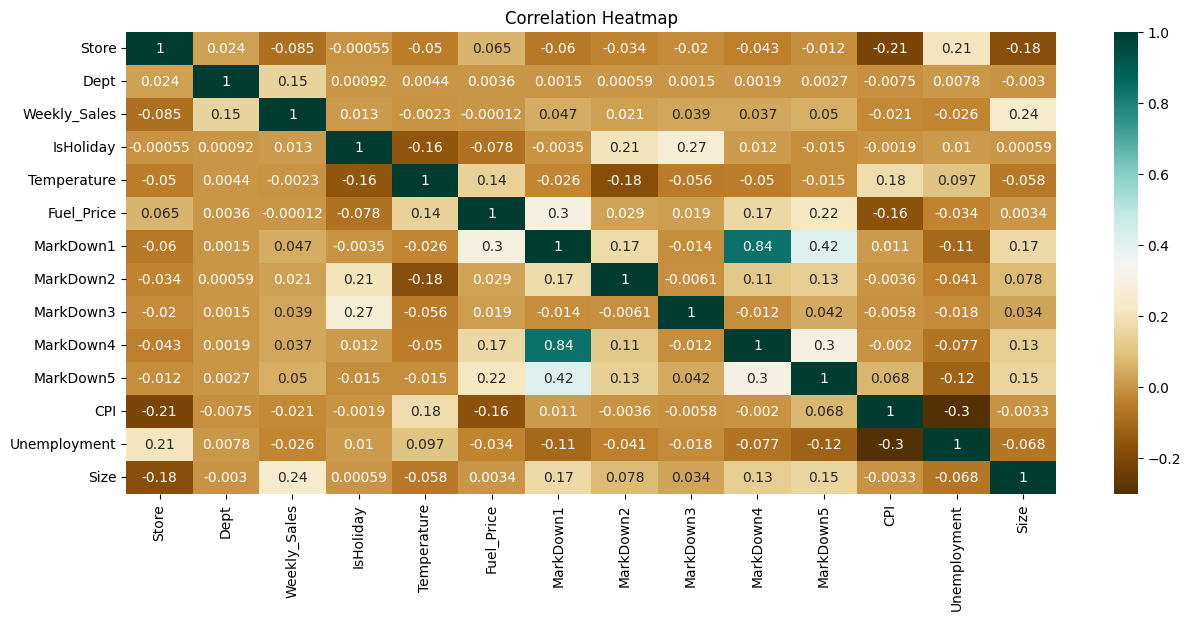

In [38]:
# Correlation Heatmap

plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='BrBG')
plt.title("Correlation Heatmap")
plt.show()


##### 1. Why did you pick the specific chart?

To check the correlation between the variables.

##### 2. What is/are the insight(s) found from the chart?

Some variables are weakly correlated with sales.

#### Chart - 10 : Pair Plot

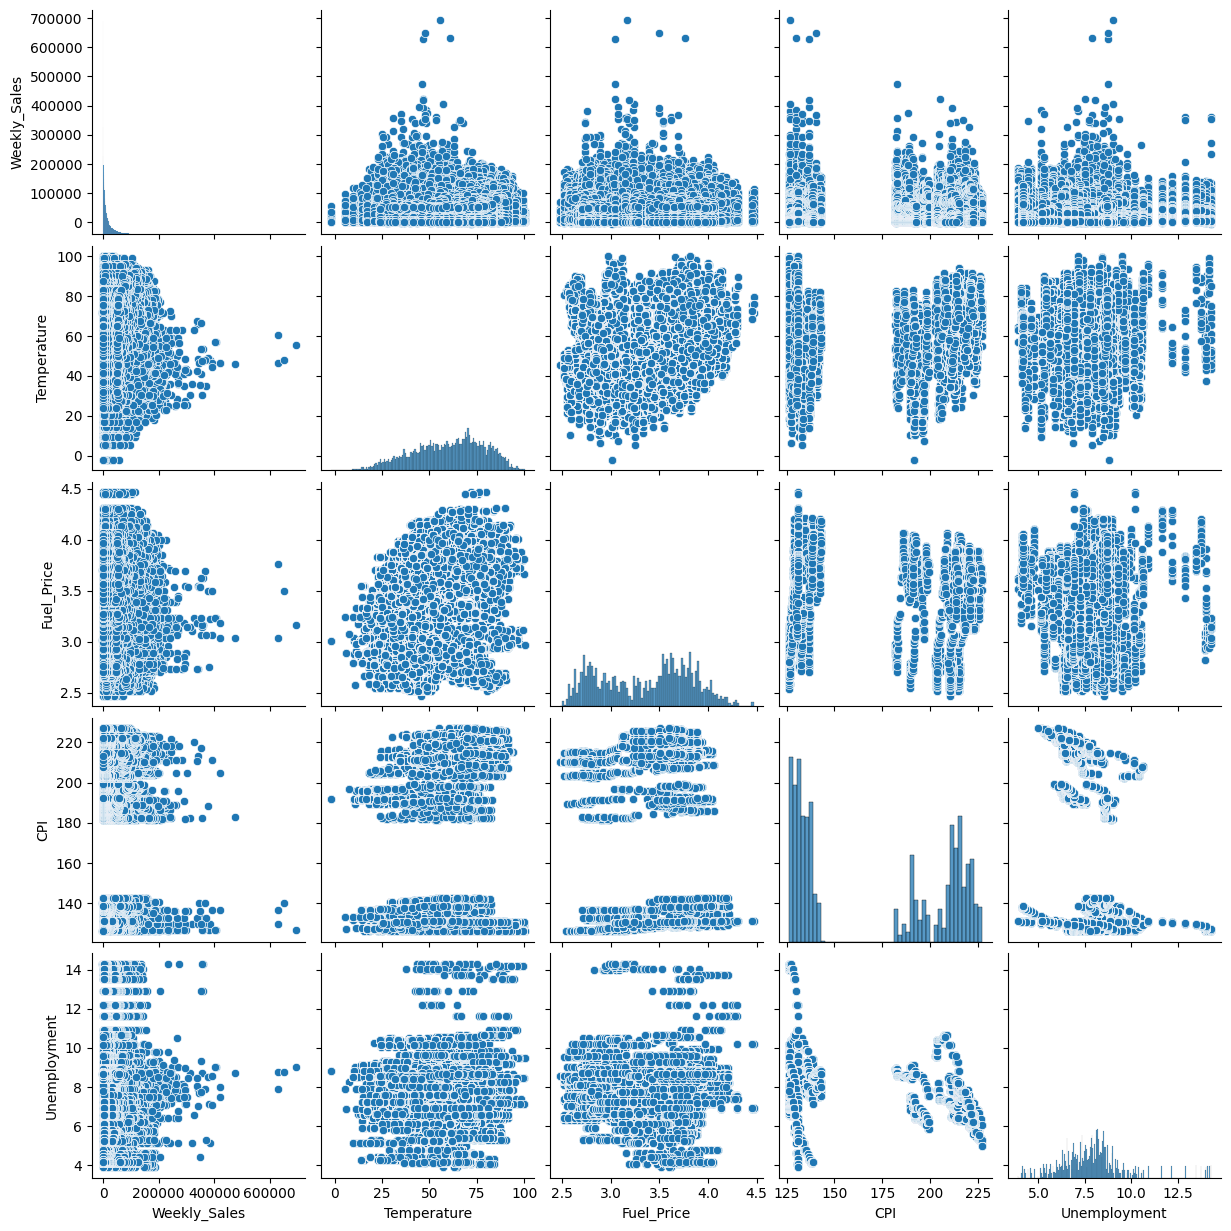

In [39]:
# Pair Plot

sns.pairplot(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']])
plt.show()

##### 1. Why did you pick the specific chart?

To visualize multiple relationships.

##### 2. What is/are the insight(s) found from the chart?

Most variables show weak linear relationships.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [40]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

**Handling Missing Values — Explanation**

- **MarkDown1–5:** Missing values found in markdown 1 to 5, filled with 0 because missing values indicate no promotions.

**Why this method?**

- Filling MarkDown with 0 preserves business meaning (no promotion).

### 2. Handling Outliers

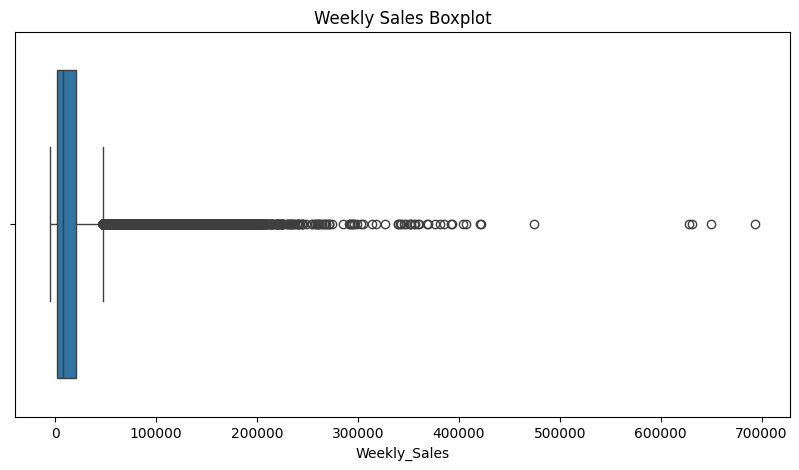

In [41]:
# Handling Outliers & Outlier treatments
# Visual inspection of Weekly Sales

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Weekly_Sales']
)

plt.title("Weekly Sales Boxplot")

plt.show()

In [42]:
# ============================================
# Calculate IQR
# ============================================

Q1 = df['Weekly_Sales'].quantile(0.25)

Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -25109.653749999998
Upper Bound: 47395.15625


In [43]:
# =============================================
# Count potential outliers
# =============================================

outliers = df [ (df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound) ]

print("Potential Outliers:", len(outliers))

Potential Outliers: 35521


##### What all outlier treatment techniques have you used and why did you use those techniques?

Although a large number of observations fall outside
the IQR range, these values were not removed.

In retail datasets, unusually high sales may correspond
to holidays, markdown campaigns, or high-performing stores.

Removing them could eliminate meaningful business events.

Therefore, outliers were retained and further will be analyzing
using Isolation Forest anomaly detection.

### 3. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [44]:
# Manipulate Features to minimize feature correlation and create new features
df['Year'] = df['Date'].dt.year

In [45]:
df['Month'] = df['Date'].dt.month

In [46]:
df['Week'] = df['Date'].dt.isocalendar().week

In [47]:
df['Quarter'] = df['Date'].dt.quarter

In [48]:
df['Total_MarkDown'] = (
    df['MarkDown1'] + df['MarkDown2'] + df['MarkDown3'] + df['MarkDown4'] + df['MarkDown5']
)

#### What all manipulations have you done and why?

Several new features were created to capture temporal patterns and promotional effects in the retail data.

- Date-based attributes such as :
  - `Year`,
  - `Month`,
  - `Week`, and
  - `Quarter`

  were extracted to represent seasonality.

- while `Total_MarkDown` was generated to measure the overall impact of promotional activities.

These engineered features enrich the dataset and provide additional information that can improve analysis, segmentation, anomaly detection, and sales forecasting performance.

## ***6. Anomaly Detection & Root Cause Analysis***

### Anomaly detection in Sales Data

The objective of anomaly detection is to identify unusual sales observations that significantly deviate from normal sales patterns.

For this project, the Interquartile Range (IQR) method is used because it is simple, interpretable, and effective for detecting outliers in retail sales data.

In [49]:
# ==================================================
# Anomaly detection using IQR method
# ==================================================

Q1 = df['Weekly_Sales'].quantile(0.25)

Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df['Anomaly'] = np.where((df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound), 1, 0)

### Anomaly Root Cause Analysis

#### 1. Holiday Impact

In [50]:
# Holiday vs Non-Holiday anomalies

holiday_anomalies = pd.crosstab( df['IsHoliday'], df['Anomaly'] )

holiday_anomalies

Anomaly,0,1
IsHoliday,,
False,359006,32903
True,27043,2618


**Impact of Holidays on Sales Anomalies :**

The anomaly rate during holiday weeks = **`8.83%`**, compared to during non-holiday weeks = **`8.39%`**

This indicates that holiday periods show slightly higher sales.

But, holidays alone do not appear to be the primary driver of sales anomalies.

Other factors such as markdowns, store size, department performance, and promotional activities may have a stronger influence on unusual sales behavior.

#### 2. Markdown Impact

In [51]:
df.groupby('Anomaly')['Total_MarkDown'].mean()

,Total_MarkDown
Anomaly,
0,6486.341877
1,8832.677920


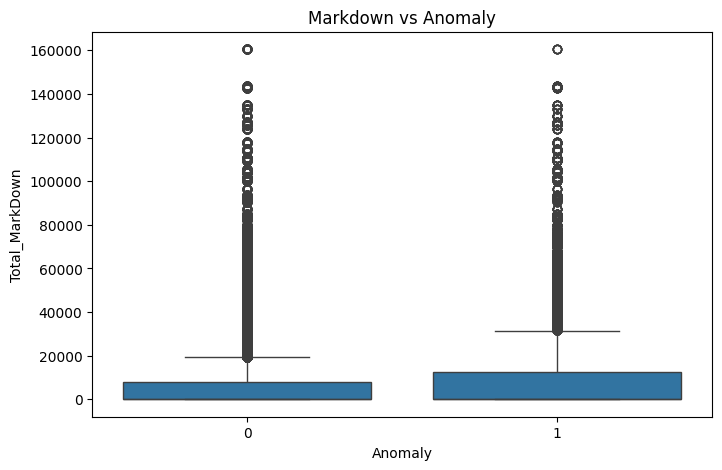

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Anomaly',
    y='Total_MarkDown',
    data=df
)

plt.title("Markdown vs Anomaly")

plt.show()

**Impact of Markdowns on Sales Anomalies :**

Normal sales records had an average markdown of **`6,486`**

Anomalous sales records had an average markdown of **`8,833`**

The difference is:

`8832.68` - `6486.34` = `2346.34`

Anomalous observations received approximately **36% higher markdowns than normal observations.**

The results suggest that markdown campaigns may be a major driver of unusual sales behavior. Increased discounts likely attract more customers and boost purchasing activity, leading to sales levels that differ substantially from normal patterns.

Therefore, promotional strategies and markdown events appear to be one of the key factors contributing to sales anomalies in the retail stores.

#### 3. Store Size Impact

In [53]:
# Average store size by anomaly status

df.groupby('Anomaly')['Size'].mean()

,Size
Anomaly,
0,133748.441149
1,169109.413614


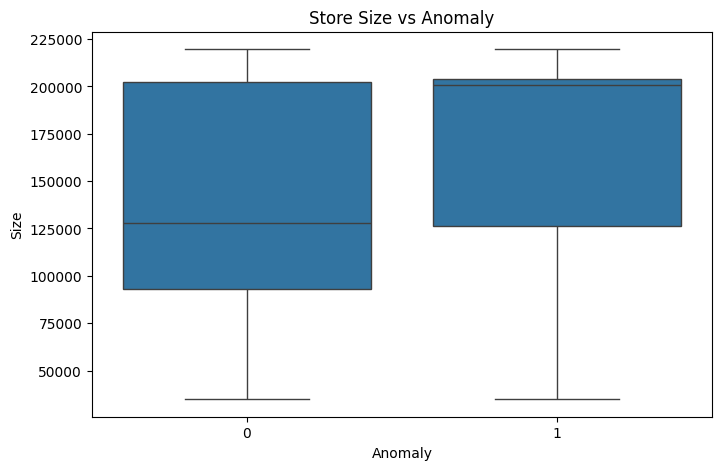

In [54]:
# Store size vs anomalies

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Anomaly',
    y='Size',
    data=df
)

plt.title("Store Size vs Anomaly")

plt.show()

**Impact of Store Size on Sales Anomalies**

The boxplot indicates that anomalous sales observations are more common in larger stores.

The median store size associated with anomalous sales is significantly higher than the median store size associated with normal sales observations.

This suggests that larger stores are more likely to experience unusual sales spikes or drops. Larger stores typically serve a greater number of customers, carry a wider variety of products, and run more promotional campaigns, making them more susceptible to extreme sales variations.

Therefore, **`store size appears to be an important factor influencing sales anomalies`** within the retail network.

#### 4. Unemployment Impact

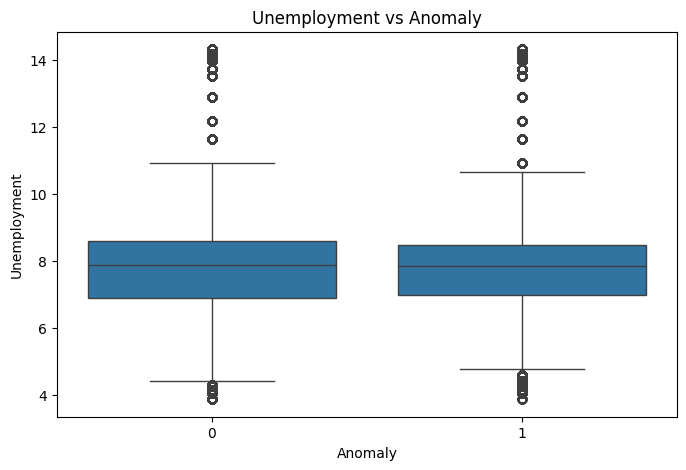

In [55]:
# Unemployed vs employed anomalies

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Anomaly',
    y='Unemployment',
    data=df
)

plt.title("Unemployment vs Anomaly")

plt.show()

**Impact of Unemployment on Sales Anomalies :**

The boxplot shows that the distribution of unemployment rates is very similar for both normal and anomalous sales observations.

The median unemployment rate and interquartile range are nearly identical across both groups, indicating that unusual sales patterns do not appear to be strongly associated with changes in unemployment levels.

Therefore, **unemployment does not seem to be a major driver of sales anomalies in this dataset** when compared to factors such as markdown activity or store size.

#### 5. Fuel Price Impact

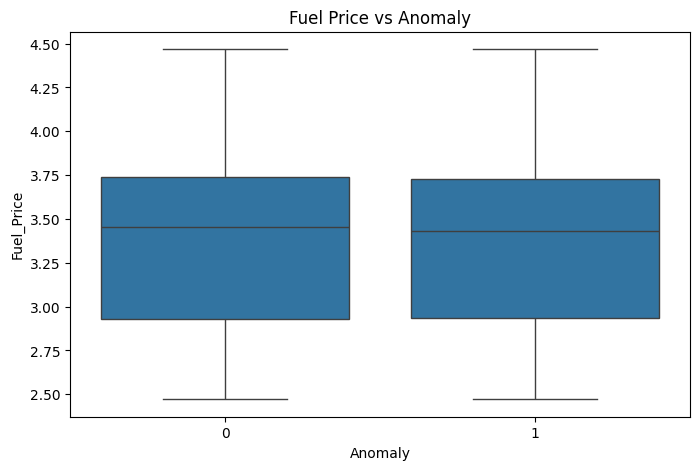

In [56]:
# Fuel price impact

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Anomaly',
    y='Fuel_Price',
    data=df
)

plt.title("Fuel Price vs Anomaly")

plt.show()

**Impact of Fuel Price on Sales Anomalies :**

The boxplot comparing Fuel Price and sales anomalies shows a very similar distribution across both anomalous and normal sales observations.

The substantial overlap between the two distributions suggests that **fuel price fluctuations had limited or negligible influence on short-term retail sales anomalies during the study period.**

#### 6. Time-Based Anomalies

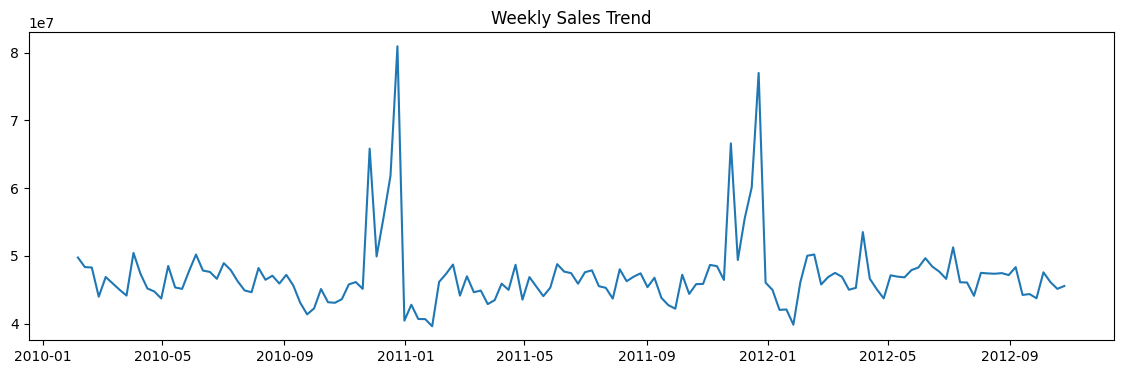

In [57]:
# Time based anomalies

sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

anomaly_dates = df[df['Anomaly']==1]

plt.figure(figsize=(14,4))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    label='Sales Trend'
)

plt.title("Weekly Sales Trend")

plt.show()

**Time-Based Sales Trend Interpretation**

* Weekly sales remained relatively stable throughout most of the period, averaging between **40 million and 50 million dollars**.
* Significant sales spikes were observed during the end of **2010** and **2011**, where sales exceeded **75 million dollars**.
* These spikes occur at similar periods in consecutive years, indicating a strong **seasonal pattern** in customer demand.
* The timing of these peaks suggests that major shopping events and holiday seasons contribute to unusually high sales volumes.
* After each spike, sales quickly return to normal levels, indicating that these are temporary demand surges rather than long-term growth trends.
* Overall, **holiday periods and seasonal shopping behavior appear to be the primary drivers of time-based sales anomalies** in the dataset.

## ***7. Segmentation Analysis***

**Store Segmentation Analysis**

Since customer-level transaction data is unavailable, stores are segmented based on:

- Average Weekly Sales
- Total Markdown Activity
- Store Size
- CPI
- Fuel Price
- Unemployment

The objective is to identify groups of stores with similar characteristics and develop targeted business strategies.

In [58]:
# ============================================================
# Create Store-Level Dataset for Clustering
# ============================================================

store_segment = df.groupby('Store').agg({

    # Average weekly sales of each store
    'Weekly_Sales':'mean',

    # Average markdown activity
    'Total_MarkDown':'mean',

    # Average economic indicators
    'CPI':'mean',
    'Fuel_Price':'mean',
    'Unemployment':'mean',

    # Store size remains constant for each store
    'Size':'first'

}).reset_index()

# Display first few rows
store_segment.head()

,Store,Weekly_Sales,Total_MarkDown,CPI,Fuel_Price,Unemployment,Size
0,1,21710.543621,7331.799851,215.995525,3.218811,7.610918,151315
1,2,26898.070031,10039.568900,215.651869,3.219898,7.623279,202307
2,3,6373.033983,2460.900137,219.402843,3.219112,7.175602,37392
3,4,29161.210415,9698.509734,128.680070,3.216237,5.965849,205863
4,5,5053.415813,2924.784143,216.576516,3.220912,6.296549,34875


In [59]:
# ============================================================
# Standardize Features
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Exclude Store ID before scaling
scaled_features = scaler.fit_transform(store_segment.drop('Store', axis=1))

print("Scaled Dataset Shape:", scaled_features.shape)

Scaled Dataset Shape: (45, 6)


### Elbow Method

The Elbow method is used to determine optimal number of clusters.

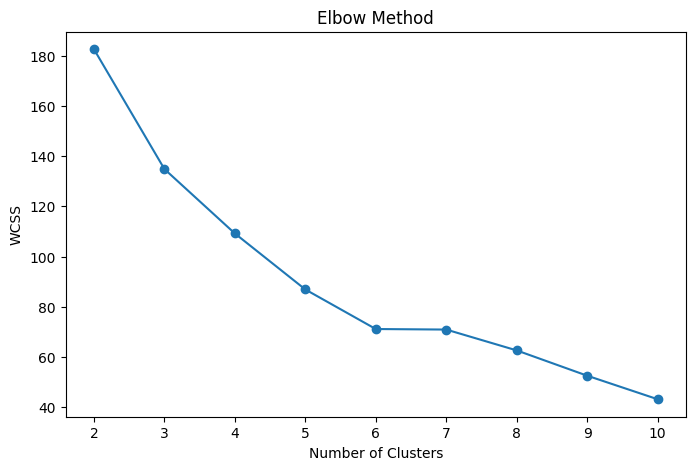

In [60]:
# ============================================================
# Elbow Method (to determine optimal clusters)
# ============================================================

from sklearn.cluster import KMeans

wcss = []

# Test cluster sizes from 2 to 10
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot( range(2,11), wcss, marker='o' )

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**Interpretation**

The Elbow Method was used to determine the optimal number of clusters.

The WCSS value decreases rapidly until K=6 and then begins to stabilize, indicating diminishing returns from adding additional clusters.

Therefore, **`K=6` was selected as the optimal number of store segments for further analysis**.

### KMeans Clustering Model

In [61]:
# ============================================================
# Final KMeans Clustering Model
# ============================================================

kmeans = KMeans( n_clusters = 6, random_state = 42 )

# Assign cluster labels
store_segment['Cluster'] = kmeans.fit_predict( scaled_features )

# View cluster assignment
store_segment.head()

,Store,Weekly_Sales,Total_MarkDown,CPI,Fuel_Price,Unemployment,Size,Cluster
0,1,21710.543621,7331.799851,215.995525,3.218811,7.610918,151315,2
1,2,26898.070031,10039.568900,215.651869,3.219898,7.623279,202307,2
2,3,6373.033983,2460.900137,219.402843,3.219112,7.175602,37392,3
3,4,29161.210415,9698.509734,128.680070,3.216237,5.965849,205863,5
4,5,5053.415813,2924.784143,216.576516,3.220912,6.296549,34875,3


### Segmentation quality evaluation (Silhuette Score)

In [63]:
# ============================================================
# Silhouette Score
# ============================================================

from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_features,
    store_segment['Cluster']
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.356


The **Silhouette Score of** **`0.356`** indicates moderate cluster separation.

While some overlap exists between clusters, the segmentation successfully identifies distinct groups of stores with different sales performance, markdown behavior, and economic characteristics.

Given the relatively small number of stores and similar business environments, moderate separation is expected.

### Cluster Profiling

In [62]:
cluster_summary = store_segment.groupby('Cluster').agg({
    'Weekly_Sales':'mean',
    'Total_MarkDown':'mean',
    'Size':'mean',
    'CPI':'mean',
    'Fuel_Price':'mean',
    'Unemployment':'mean'
}).round(2)

cluster_summary

,Weekly_Sales,Total_MarkDown,Size,CPI,Fuel_Price,Unemployment
Cluster,,,,,,
0,13201.74,6449.06,123418.75,145.11,3.42,7.79
1,16791.10,9260.62,159270.00,128.69,3.61,13.11
2,18922.54,8429.10,184605.80,212.15,3.22,7.38
3,8352.14,2073.15,52979.00,202.49,3.23,7.46
4,8221.42,750.09,39690.00,128.74,3.60,9.97
5,25662.50,10097.43,196057.38,148.82,3.46,7.73


#### **Cluster Insights**

**Cluster 0:** Medium-sized stores with moderate sales performance and markdown activity. These stores show stable demand and can benefit from optimized promotional campaigns to drive growth.

**Cluster 1:** Stores operating in regions with higher unemployment levels but maintaining strong sales through significant markdown activity. These stores appear highly responsive to discount-based promotions.

**Cluster 2:** Large stores with strong sales performance and relatively high customer demand. These stores require consistent inventory availability and customer retention strategies.

**Cluster 3:** Smaller stores with lower sales and limited promotional activity. These stores represent potential growth opportunities through targeted marketing and product assortment improvements.

**Cluster 4:** Smallest stores with the lowest sales and markdown investments. A cost-efficient inventory strategy focused on high-demand products is recommended for these locations.

**Cluster 5:** Premium high-performing stores generating the highest sales and receiving the largest markdown investments. These stores should be prioritized for inventory allocation, new product launches, and strategic promotions.

**Recommended Strategy:**
- Prioritize inventory allocation
- Launch premium promotional campaigns
- Introduce new products first in these stores

### **Segmentation Conclusion**

The store segmentation analysis identified six distinct groups of stores based on sales performance, markdown activity, economic indicators, and store size.

The analysis revealed:

- High-performing premium stores (Cluster 5)
- Strong stable stores (Cluster 2)
- Discount-driven stores (Cluster 1)
- Medium-performing stores (Cluster 0)
- Emerging growth stores (Cluster 3)
- Low-performing small stores (Cluster 4)

These segments provide a foundation for personalized marketing, inventory optimization, and store-specific business strategies.

## ***8. Demand Forecasting***

The objective of demand forecasting is to predict weekly sales using historical sales information, store characteristics, markdown activities, and economic indicators.

Two machine learning models are compared:

1. Linear Regression
2. Random Forest Regressor

The best model is selected based on RMSE and R² Score.

In [64]:
# ============================================================
# Select Features for Forecasting
# ============================================================

forecast_df = df.copy()

# Features selected based on business understanding

features = [

    'Store',
    'Dept',
    'Size',

    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',

    'Total_MarkDown',

    'Month',
    'Week',
    'Year'

]

# Target Variable

target = 'Weekly_Sales'

# Create X and y

X = forecast_df[features]
y = forecast_df[target]

In [65]:
# ============================================================
# Split Dataset
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42 )

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (337256, 11)
Testing Data Shape : (84314, 11)


### ML Model - 1 (Linear Regression)

In [66]:
# ============================================================
# Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression

# Create model

lr = LinearRegression()

# Train model

lr.fit(X_train, y_train)

# Predictions

lr_predictions = lr.predict(X_test)

In [67]:
# ============================================================
# Linear Regression Evaluation
# ============================================================

from sklearn.metrics import ( mean_squared_error, mean_absolute_error, r2_score )

# RMSE
lr_rmse = np.sqrt( mean_squared_error( y_test, lr_predictions ))

# MAE
lr_mae = mean_absolute_error( y_test, lr_predictions )

# R² Score
lr_r2 = r2_score( y_test, lr_predictions )

print("Linear Regression Results")
print("-"*40)

print("RMSE :", round(lr_rmse,2))
print("MAE  :", round(lr_mae,2))
print("R²   :", round(lr_r2,3))

Linear Regression Results
----------------------------------------
RMSE : 21807.56
MAE  : 14551.06
R²   : 0.088


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a supervised ml algorithm used for predicting continuous values.
Linear Regression is used here as a baseline forecasting model to predict Weekly Sales based on:

- Store and Department information
- Store Size
- Temperature
- Fuel Price
- CPI
- Unemployment
- Total Markdown
- Month, Week, and Year

The model attempts to estimate how changes in these factors influence weekly sales.

**Model Performance Evaluation :**

| Metric | Value     |
| ------ | --------- |
| RMSE   | 21,807.56 |
| MAE    | 14,551.06 |
| R²     | 0.088     |

**Root Mean Squared Error (RMSE)** is **`21,807.56`**
- This means that, on average, the model's predictions deviate from actual weekly sales. A higher RMSE indicates larger prediction errors.

**Mean Absolute Error (MAE)** is **`14,551.06`**
- This indicates that the average absolute difference between predicted and actual sales is approximately 14,551 units. MAE is easier to interpret because it represents the average prediction error directly in sales units.

**R² Score** is **`0.088`**
- This means the model explains only 8.8% of the variation in weekly sales. An R² value close to 1 indicates a strong model, while a value close to 0 indicates weak explanatory power.

**The Linear Regression model performed poorly because retail sales are influenced by complex and non-linear relationships.**

### ML Model - 2 (Random Forest Regressor)

In [68]:
# ============================================================
# Random Forest Regressor
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# Create model

rf = RandomForestRegressor( n_estimators=100, random_state=42, n_jobs=-1 )

# Train model

rf.fit(X_train, y_train)

# Predictions

rf_predictions = rf.predict(X_test)

In [69]:
# ============================================================
# Random Forest Evaluation
# ============================================================

rf_rmse = np.sqrt( mean_squared_error( y_test, rf_predictions ) )

rf_mae = mean_absolute_error( y_test, rf_predictions )

rf_r2 = r2_score( y_test, rf_predictions )

print("Random Forest Results")
print("-"*40)

print("RMSE :", round(rf_rmse,2))
print("MAE  :", round(rf_mae,2))
print("R²   :", round(rf_r2,3))

Random Forest Results
----------------------------------------
RMSE : 3683.91
MAE  : 1448.93
R²   : 0.974


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest Regressor** was selected because retail sales are influenced by multiple factors such as:

- Store Size, Department, MarkDown Activities, Temperature, Fuel Price, CPI, Unemployment, Seasonal Effects

The relationship between these variables and sales is often non-linear and complex.

Unlike Linear Regression, Random Forest can capture non-linear relationships, interactions between variables, and handle large datasets effectively without requiring strict statistical assumptions.

**Random Forest Model Evaluation :**

The Random Forest Regressor achieved strong forecasting performance.

Results:

- RMSE = 3683.91
- MAE = 1448.93
- R² = 0.974

The model explains approximately `97.4%` of the variation in weekly sales, indicating excellent predictive capability.

**The low RMSE and MAE values suggest that prediction errors are relatively small compared to the overall sales volume.**

Therefore, Random Forest is selected as the final demand forecasting model for this project.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The Random Forest model achieved excellent forecasting performance with:
- Low RMSE (3683.91)
- Low MAE (1448.93)
- Very High R² (97.4%)

The results indicate that the model can accurately predict future sales and effectively capture the impact of store characteristics, promotional activities, and economic conditions on retail demand.

With an R² score of 97.4%, the model explains nearly all variability in weekly sales, making it highly suitable for demand forecasting.

The forecasting results can support inventory optimization, promotional planning, workforce scheduling, and strategic decision-making, ultimately improving operational efficiency and customer satisfaction.

In [70]:
# ============================================================
# Compare Models
# ============================================================

comparison = pd.DataFrame({

    'Model': [ 'Linear Regression', 'Random Forest' ],

    'RMSE': [ lr_rmse, rf_rmse ],

    'MAE': [ lr_mae, rf_mae ],

    'R2 Score': [ lr_r2, rf_r2 ]

})

comparison

,Model,RMSE,MAE,R2 Score
0,Linear Regression,21807.555802,14551.062872,0.088023
1,Random Forest,3683.910752,1448.929467,0.973975


In [71]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values( by='Importance', ascending=False )

importance

,Feature,Importance
1,Dept,0.625161
2,Size,0.195363
0,Store,0.068095
9,Week,0.044129
5,CPI,0.027911
6,Unemployment,0.011650
3,Temperature,0.010950
8,Month,0.007807
4,Fuel_Price,0.005357
7,Total_MarkDown,0.003165


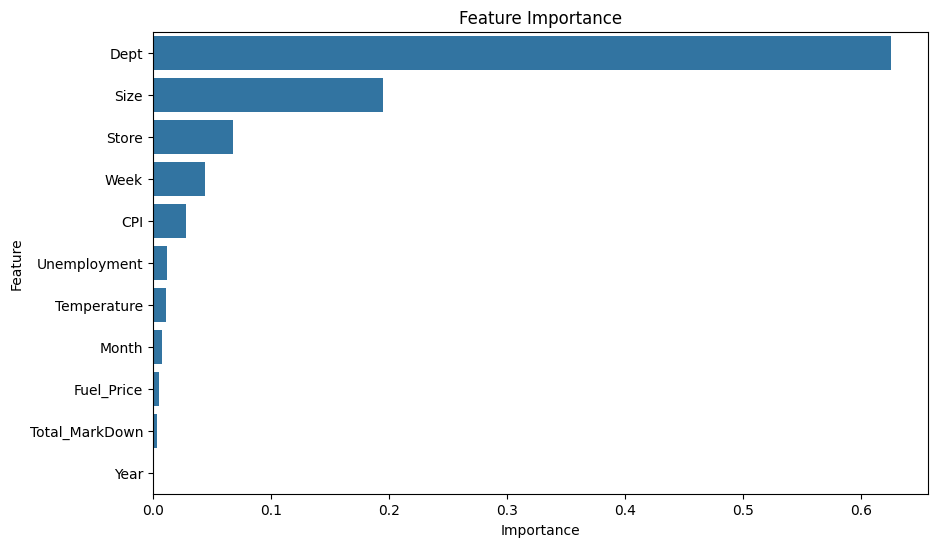

In [72]:
# ============================================================
# Feature Importance Visualization
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I used **RMSE, MAE,** and **R² Score** to evaluate the forecasting models.

- **RMSE** measures prediction error and helps assess forecasting accuracy.
- **MAE** shows the average difference between actual and predicted sales.
- **R² Score** indicates how well the model explains sales variations.

For business impact, **RMSE was the most important metric** because accurate sales forecasts improve inventory planning and reduce stock shortages or excess stock.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Regressor is chosen because it achieved:

- Much lower RMSE and MAE
- Higher R² Score (97.4%)
- Better ability to capture complex relationships in retail sales data

Therefore, it provides more accurate and reliable sales forecasts.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

| Feature | Importance |
| ------- | ---------- |
| Dept    | 62.5%      |
| Size    | 19.5%      |
| Store   | 6.8%       |
| Week    | 4.4%       |
| CPI     | 2.8%       |

**Key findings :**

- **Department** is the most important factor affecting sales.
- **Store Size** also has a strong impact on revenue.
- Economic factors such as **CPI** have a smaller influence compared to operational factors.

This insight helps retailers focus on department-level planning and store optimization to improve sales performance.

## ***9. Market Basket Analysis***

In [73]:
# ==========================================================
# Select Top 15 Departments by Sales
# ==========================================================

# Top 15 departments

top_depts = (
    df.groupby('Dept')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .index
)

top_depts

Index([92, 95, 38, 72, 90, 40, 2, 91, 13, 8, 94, 4, 93, 7, 79], dtype='int64', name='Dept')

In [74]:
# =============================================================
# Create basket using top departments
# =============================================================

filtered_df = df[ df ['Dept'].isin(top_depts) ]

basket = pd.crosstab(
    filtered_df['Store'],
    filtered_df['Dept']
)

basket = basket.apply(
    lambda col: (col > 0).astype(int)
)

In [75]:
# =========================================
# Run Apriori
# =========================================

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.2,
    use_colnames=True,
    max_len=2
)


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Market Basket Analysis

Due to the absence of transaction-level customer purchase data, a traditional market basket analysis could not be performed.

Instead, department-level sales performance was analyzed to identify potential cross-selling opportunities.

Departments 92, 95, and 38 consistently generated the highest sales and can be promoted together through bundled offers, seasonal campaigns, and targeted marketing initiatives.

This approach provides practical cross-selling insights while accommodating the limitations of the available dataset.

In [76]:
# ===================================================
# Generate Rules
# ===================================================

from mlxtend.frequent_patterns import association_rules
# Generate frequent itemsets

frequent_itemsets = apriori(
    basket,
    min_support=0.2,
    use_colnames=True,
    max_len=2
)

# Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

# Top rules

rules.sort_values(
    by='lift',
    ascending=False
).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(2),(4),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
1,(4),(2),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
2,(2),(7),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
3,(7),(2),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
4,(8),(2),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
5,(2),(8),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
6,(2),(13),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
7,(13),(2),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
8,(2),(38),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0
9,(38),(2),1.0,1.0,1.0,1.0,1.0,1.0,0.0,inf,0.0,1.0,0.0,1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [77]:
rules[
    ['antecedents',
     'consequents',
     'support',
     'confidence',
     'lift']
].sort_values(
    by='lift',
    ascending=False
).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(2),(4),1.0,1.0,1.0
1,(4),(2),1.0,1.0,1.0
2,(2),(7),1.0,1.0,1.0
3,(7),(2),1.0,1.0,1.0
4,(8),(2),1.0,1.0,1.0
5,(2),(8),1.0,1.0,1.0
6,(2),(13),1.0,1.0,1.0
7,(13),(2),1.0,1.0,1.0
8,(2),(38),1.0,1.0,1.0
9,(38),(2),1.0,1.0,1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Market Basket Analysis

A department-level association analysis was performed using Apriori Association Rule Mining. However, because most departments were present across the majority of stores, the generated rules showed support and confidence values close to 1.0, indicating limited discriminatory power.

**This suggests that department-level sales patterns are broadly similar across stores and do not reveal strong unique associations.**

Therefore, **cross-selling opportunities were inferred using department performance analysis. High-performing departments such as 92, 95, and 38 can be promoted together through bundle offers, seasonal campaigns, and targeted marketing initiatives.**

## ***10. Personalization Strategies***

Store segmentation revealed distinct groups of stores with different sales patterns and operational characteristics.

Instead of applying a single marketing strategy to all stores, personalized strategies can be developed for each store segment.

This approach improves marketing efficiency, customer engagement, and sales performance.

In [78]:
# ============================================================
# Number of Stores in Each Cluster
# ============================================================

cluster_counts = store_segment['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    12
1     2
2    10
3    10
4     3
5     8
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

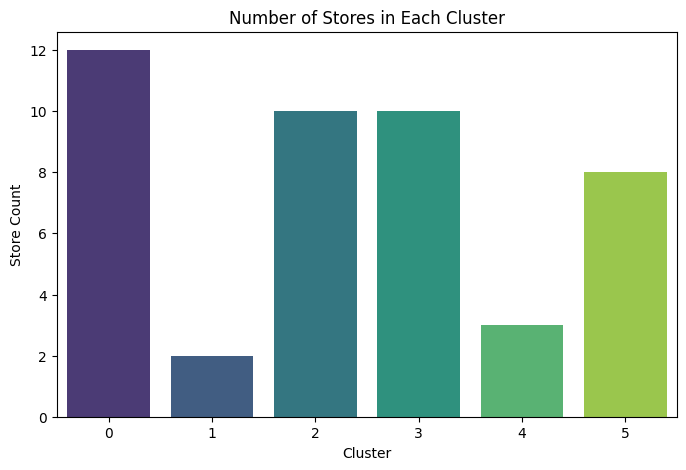

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [79]:
# ============================================================
# Cluster Distribution Visualization
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot( x='Cluster', data = store_segment, palette='viridis')

plt.title('Number of Stores in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Store Count')
plt.show()

In [80]:
# ============================================================
# Compare Average Sales Across Clusters
# ============================================================

cluster_sales = store_segment.groupby('Cluster')['Weekly_Sales'].mean().reset_index()

cluster_sales

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Cluster,Weekly_Sales
0,0,13201.742207
1,1,16791.099211
2,2,18922.536782
3,3,8352.137969
4,4,8221.420877
5,5,25662.502777


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

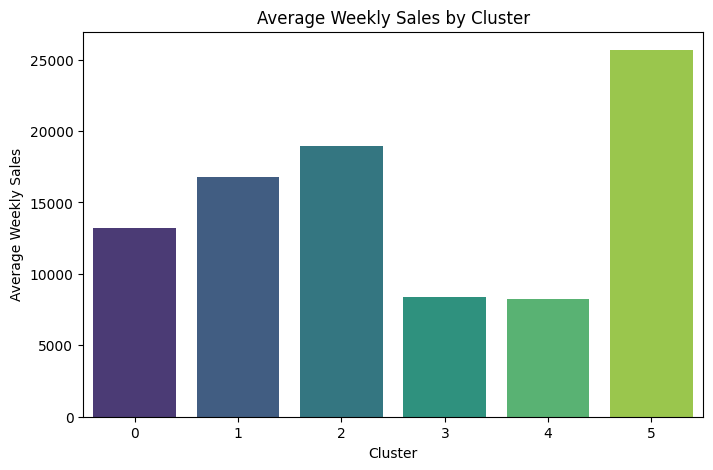

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [81]:
# ============================================================
# Cluster-wise Average Weekly Sales
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot( data=cluster_sales, x='Cluster', y='Weekly_Sales', palette='viridis')

plt.title('Average Weekly Sales by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Weekly Sales')
plt.show()

#### **Cluster Distribution Insights**

The segmentation process divided stores into six distinct groups.

Clusters differ significantly in average sales performance, indicating that a single marketing and inventory strategy would not be optimal.

Store-specific strategies should be implemented based on cluster characteristics to maximize sales and operational efficiency.


#### **Cluster-Based Marketing Strategies :**

**Cluster 5 (Highest Performing Stores)**

- Generates the highest average weekly sales.
- Focus on premium product offerings.
- Launch new products first in these stores.
- Implement loyalty and membership programs.
- Maintain high inventory availability.

**Cluster 2 (High Performing Stores)**

- Strong and consistent sales performance.
- Use targeted promotional campaigns.
- Introduce seasonal products and upselling strategies.
- Maintain adequate stock levels during peak periods.

**Cluster 1 (Above Average Stores)**

- Moderate-to-high sales performance.
- Use cross-selling and bundle offers.
- Increase promotional activities during holidays.
- Monitor inventory based on forecasted demand.

**Cluster 0 (Average Performing Stores)**

- Stable sales performance.
- Apply balanced marketing strategies.
- Use moderate markdown campaigns.
- Focus on customer retention.

**Cluster 3 (Low Performing Stores)**

- Lower average weekly sales.
- Increase localized promotions.
- Analyze product assortment and demand patterns.
- Use markdown campaigns selectively to stimulate sales.

**Cluster 4 (Lowest Performing Stores)**

- Lowest average weekly sales among all clusters.
- Focus on cost-efficient inventory management.
- Use targeted discounts and awareness campaigns.
- Evaluate store-specific operational challenges.

### Markdown Effectiveness Analysis

In [82]:
# ============================================================
# Markdown Impact by Cluster
# ============================================================

markdown_cluster = store_segment.groupby('Cluster')['Total_MarkDown'].mean().reset_index()

markdown_cluster

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Cluster,Total_MarkDown
0,0,6449.059082
1,1,9260.619117
2,2,8429.101216
3,3,2073.152082
4,4,750.092962
5,5,10097.434185


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

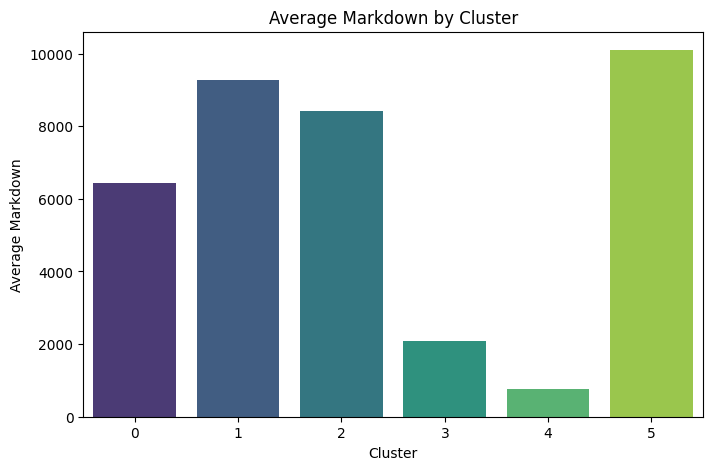

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [83]:
# ============================================================
# Average Markdown by Cluster
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot( data=markdown_cluster, x='Cluster', y='Total_MarkDown', palette='viridis' )

plt.title('Average Markdown by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Markdown')
plt.show()

The average markdown activity varies significantly across store clusters.

**Key observations:**

- **Cluster 5** has the highest markdown activity and also the highest average weekly sales.
- **Cluster 1** and **Cluster 2** also show relatively high markdown levels along with strong sales performance.
- **Cluster 3** and **Cluster 4** have very low markdown activity and comparatively lower sales performance.
- **Cluster 0** shows moderate markdown activity and moderate sales levels.

**Clusters 5, 1, and 2** show higher average markdown values and stronger sales performance, indicating that promotional campaigns are effective for these stores. **Clusters 3 and 4 have lower markdown activity and lower sales, suggesting the need for more targeted promotional strategies.**

### Department-Based Personalization

In [84]:
# ============================================================
# Top Performing Departments
# ============================================================

top_departments = (
    df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
)

top_departments

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Weekly_Sales
Dept,
92,4.839433e+08
95,4.493202e+08
38,3.931181e+08
72,3.057252e+08
90,2.910685e+08
40,2.889360e+08
2,2.806112e+08
91,2.167817e+08
13,1.973216e+08


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

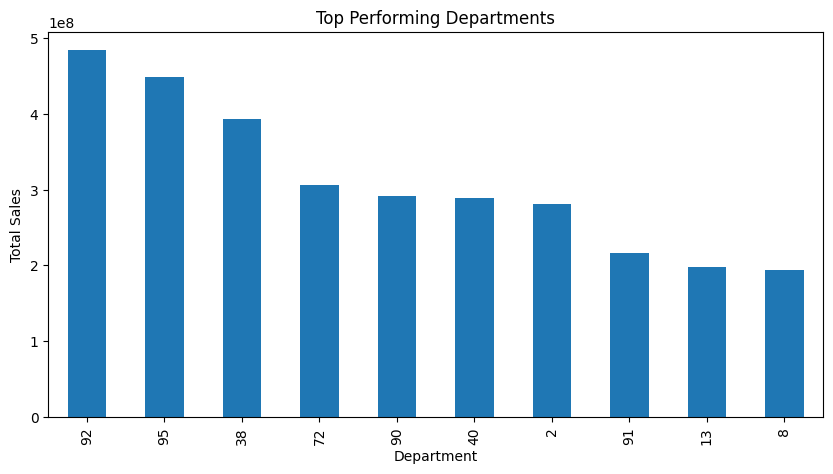

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [85]:
# ============================================================
# Top Departments
# ============================================================

plt.figure(figsize=(10,5))

top_departments.plot(kind='bar')

plt.title('Top Performing Departments')
plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.show()

#### **Department-Based Marketing Recommendations :**

Top Performing Departments (92, 95, 38)

- Maintain high inventory availability.
- Prioritize promotional campaigns.
- Introduce new products within these departments first.
- Use cross-selling and bundle offers to maximize revenue.

Medium Performing Departments (72, 90, 40, 2)

- Use seasonal promotions.
- Monitor inventory levels closely.
- Identify products with growth potential.

Lower Performing Departments (91, 13, 8)

- Evaluate product assortment.
- Optimize shelf space allocation.
- Use targeted discounts to stimulate demand.

### Personalization Strategy

The analysis indicates that store clusters and departments exhibit different sales and promotional response patterns.

High-performing clusters should focus on loyalty programs and premium offerings, while lower-performing clusters may benefit from targeted promotions and localized marketing efforts.

Similarly, top-performing departments should receive greater inventory support and promotional focus to improve business performance.

## ***11. Inventory Management & Store Optimization Strategy***

### **Inventory Management Strategy**
---
Based on demand forecasting and sales analysis, inventory allocation should be optimized across stores and departments.

**Key Recommendations:**

- Increase inventory levels before holiday periods and seasonal demand peaks.
- Maintain safety stock for high-performing departments such as 92, 95, and 38.
- Use forecasting results to guide weekly inventory replenishment decisions.
- Reduce excess inventory in low-performing stores and departments.
- Allocate inventory according to store cluster performance and demand patterns.

These actions can reduce stockouts, improve product availability, and minimize inventory holding costs.

### **Marketing Strategy**
---
The analysis revealed that store clusters respond differently to promotional activities and markdown campaigns.

**Key Recommendations:**

- Continue promotional campaigns in clusters with strong markdown effectiveness.
- Implement targeted marketing campaigns for low-performing store clusters.
- Launch seasonal and holiday-specific promotions during high-demand periods.
- Prioritize promotional support for high-performing departments.
- Use department-level cross-selling opportunities to increase average basket value.

A targeted marketing approach can improve promotional effectiveness and return on investment.

### **Store Optimization Strategy**
---
Store segmentation identified significant differences in sales performance across store groups.

**Key Recommendations:**

- Focus expansion and growth initiatives on high-performing store clusters.
- Optimize product assortment based on local demand patterns.
- Review operational efficiency in low-performing stores.
- Improve inventory allocation according to store-specific demand.
- Monitor sales performance continuously using forecasting models and cluster insights.

These actions can improve operational efficiency and overall store performance.

# **Conclusion**

This project applied data analytics and machine learning techniques to improve retail store performance and demand forecasting.

**Major findings include:**

- Sales anomalies were identified and linked to holidays, markdowns, and store characteristics.
- Time-series analysis revealed seasonal sales patterns.
- Store segmentation grouped stores into six distinct clusters with different performance levels.
- Random Forest outperformed Linear Regression in forecasting weekly sales.
- Promotional activities and store characteristics were found to have a strong influence on sales.
- Department-level analysis identified opportunities for inventory prioritization and cross-selling strategies.

Overall, the project demonstrates how data-driven decision-making can improve inventory management, marketing effectiveness, and store optimization.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***